# Spotify Music Analysis with Seaborn

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Discover patterns in Spotify songs
- Explore relationships between audio features
- Practice statistical visualizations using Seaborn


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/spotify-tracks.csv")

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# Data Exploration & Cleaning
print("data info:", df.info())
print("data description:", df.describe())
print("null values:", df.isnull().sum())
print("duplicated rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicated rows after dropping:", df.duplicated().sum())
df["track_genre"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [3]:
# Data Visualization General Settings
spotify_green = "#1DB954"
bg = "#110E28"

sns.set_theme(style="darkgrid", palette=[spotify_green])

plt.rcParams.update(
    {
        "figure.facecolor": bg,
        "axes.facecolor": "#181537",
        "axes.edgecolor": "white",
        "axes.labelcolor": "white",
        "axes.titlecolor": "white",
        "xtick.color": "white",
        "ytick.color": "white",
        "text.color": "white",
        "grid.color": "#404040",
        "figure.figsize": (12, 8),
        "font.size": 12,
    }
)

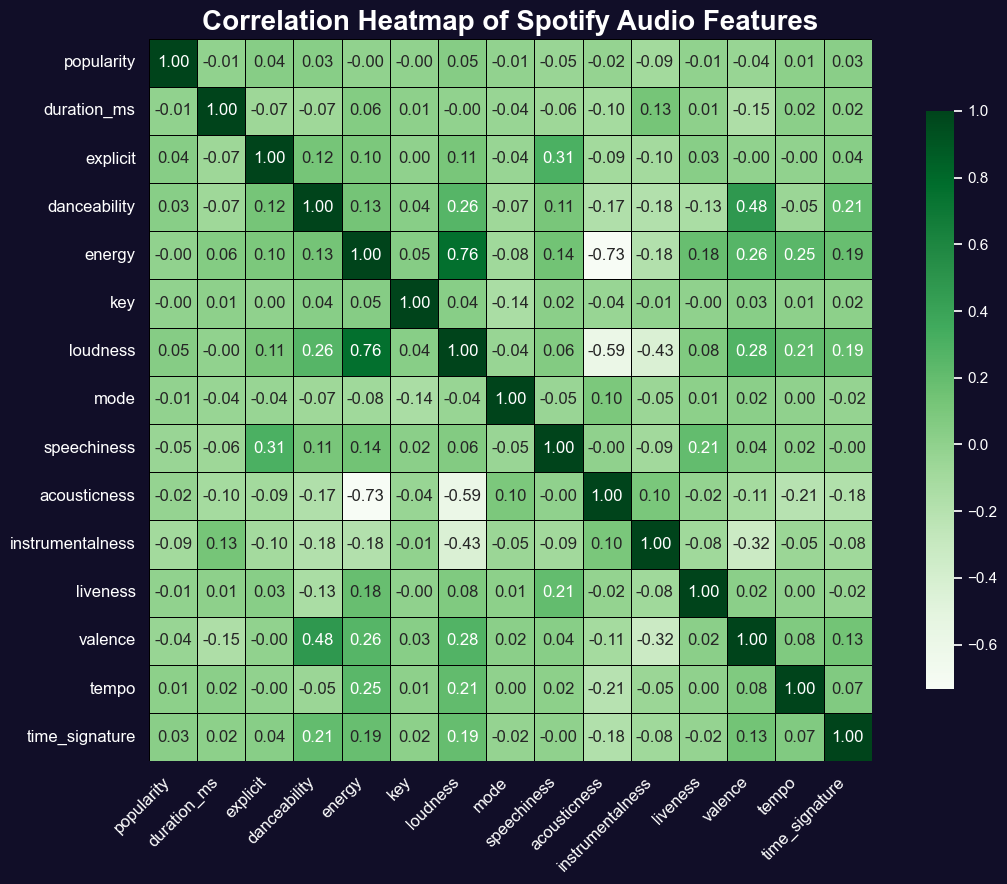

In [4]:
# 1. Correlation Heatmap
# Question: How do the audio features of Spotify tracks correlate with each other?

corr = df.corr(
    numeric_only=True
)  # corr() makes a correlation matrix of the numerical columns in the dataframe. The correlation matrix shows how each numerical column is related to every other numerical column in the dataframe. The values in the correlation matrix range from -1 to 1, where -1 indicates a strong negative correlation, 0 indicates no correlation, and 1 indicates a strong positive correlation.
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,  # annot=True adds the correlation values to the heatmap.
    fmt=".2f",  # fmt=".2f" formats the correlation values to two decimal places.
    cmap="Greens",  # cmap="Greens" sets the color scheme for the heatmap.
    linewidths=0.5,  # linewidths=0.5 sets the width of the lines between cells.
    linecolor="black",  # linecolor="white" sets the color of the lines between cells.
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Correlation Heatmap of Spotify Audio Features",
    fontsize=20,
    fontweight="bold",
)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight: The heatmap shows the correlation between different audio features of Spotify tracks. For example, we can see that "energy" and "loudness" have a strong positive correlation, while "acousticness" and "energy" have a strong negative correlation. This information can be useful for understanding how different audio features relate to each other and can help in making decisions about music production and playlist curation.

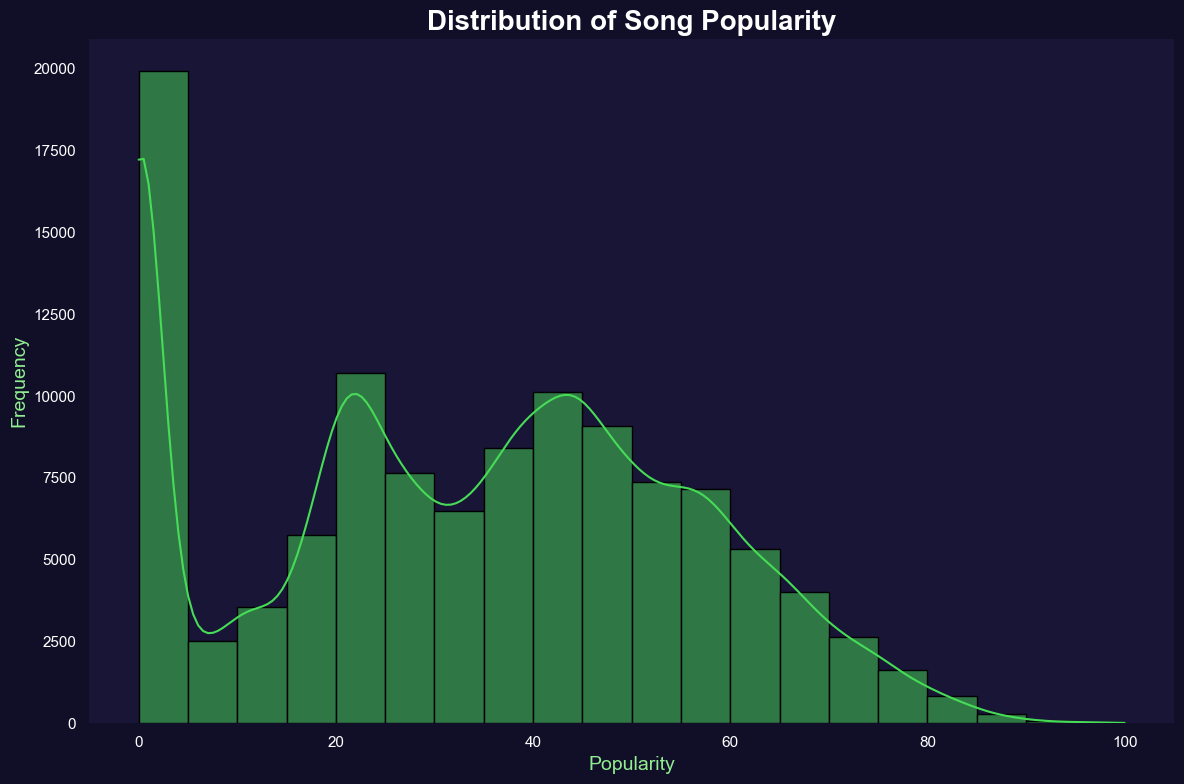

In [5]:
# 2. Histogram of Popularity
# Question: What is the distribution of popularity scores for Spotify tracks?

sns.histplot(
    df["popularity"], bins=20, kde=True, edgecolor="black", color="#47DC56"
)  # kde stands for Kernel Density Estimation, which is a way to estimate the probability density function of a continuous random variable. It is used to visualize the distribution of data points in a dataset.
# The kde parameter in the histplot() function adds a smooth curve to the histogram that represents the estimated density of the data points.
plt.title("Distribution of Song Popularity", fontsize=20, fontweight="bold")
plt.xlabel("Popularity", fontsize=14, color="lightgreen")
plt.ylabel("Frequency", fontsize=14, color="lightgreen")
sns.despine(
    left=True, bottom=True
)  # despine() removes the top and right spines from the plot.(inner border)
plt.grid(False)
plt.tight_layout()
plt.savefig(
    "../images/popularity_distribution.png", dpi=300, bbox_inches="tight"
)  # bbox_inches="tight" removes any extra whitespace around the plot when saving it as an image.
plt.show()

# Insight: The histogram shows the distribution of popularity scores for Spotify tracks. We can see that most tracks have a popularity score between 20 and 60, with a peak around 40. There are fewer tracks with very high or very low popularity scores. This information can be useful for understanding the general popularity of songs on Spotify and can help in making decisions about music promotion and marketing strategies.

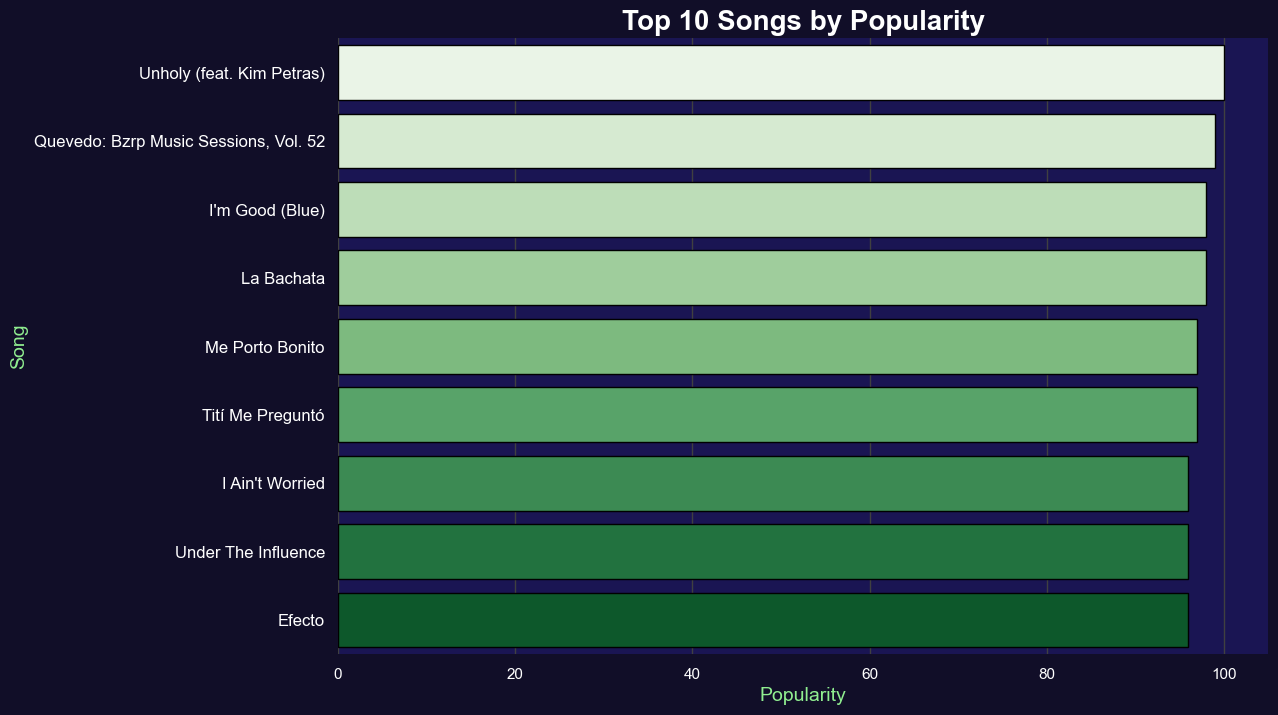

,track_name,popularity
20001,Unholy (feat. Kim Petras),100
81051,Unholy (feat. Kim Petras),100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",99
81210,I'm Good (Blue),98
30003,I'm Good (Blue),98
67356,La Bachata,98
89411,La Bachata,98
20008,I'm Good (Blue),98
88410,La Bachata,98
68303,La Bachata,98


In [6]:
# 3. Bar Plot of Top 10 songs by Popularity
# Question: What are the top 10 songs of Spotify tracks in the dataset?

ax = plt.gca()
ax.set_facecolor("#1A1553")
tracks = (
    df[["track_name", "popularity"]]
    .sort_values(by="popularity", ascending=False)
    .head(25)
)
sns.barplot(
    data=tracks,
    x="popularity",
    y="track_name",
    edgecolor="black",
    hue="track_name",
    palette="Greens",
    ax=ax,
)

plt.title("Top 10 Songs by Popularity", fontsize=20, fontweight="bold")
plt.xlabel("Popularity", fontsize=14, color="lightgreen")
plt.yticks(ha="right", fontsize=12)
plt.ylabel("Song", fontsize=14, color="lightgreen")
sns.despine(left=True, bottom=True)
plt.savefig("../images/top_10_songs.png", dpi=300, bbox_inches="tight")
plt.show()
tracks
# Insight: The bar plot shows the top 10 songs ranked by popularity in the dataset.

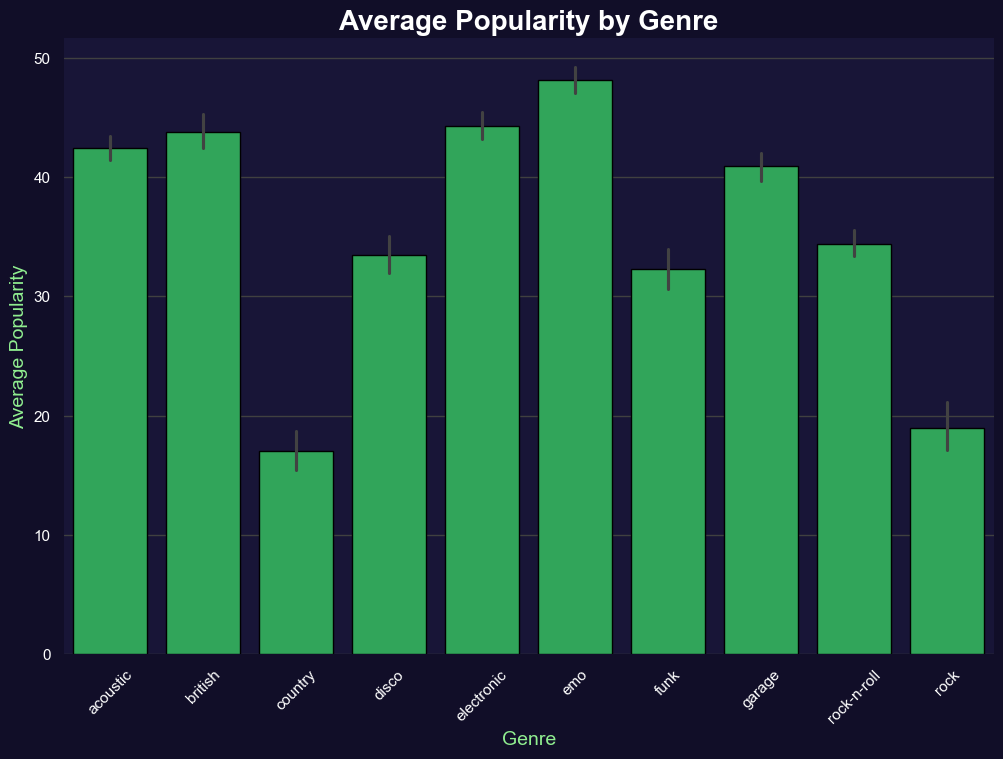

In [7]:
# 4. Average Popularity by Genre
# Question: What is the average popularity of Spotify tracks by genre?

top10 = df["track_genre"].value_counts().head(10).index
genre_df = df[df["track_genre"].isin(top10)]

sns.barplot(
    data=genre_df,
    x="track_genre",
    y="popularity",
    estimator=np.mean,
    edgecolor="black",
)

plt.xticks(rotation=45)

plt.title("Average Popularity by Genre", fontsize=20, fontweight="bold")
plt.xlabel("Genre", fontsize=14, color="lightgreen")
plt.ylabel("Average Popularity", fontsize=14, color="lightgreen")
sns.despine(left=True, bottom=True)
plt.savefig("../images/average_popularity_by_genre.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight: The bar plot shows the average popularity of Spotify tracks by genre. We can see that some genres have higher average popularity scores than others. This information can be useful for understanding which genres are more popular among Spotify users and can help in making decisions about music production and playlist curation.

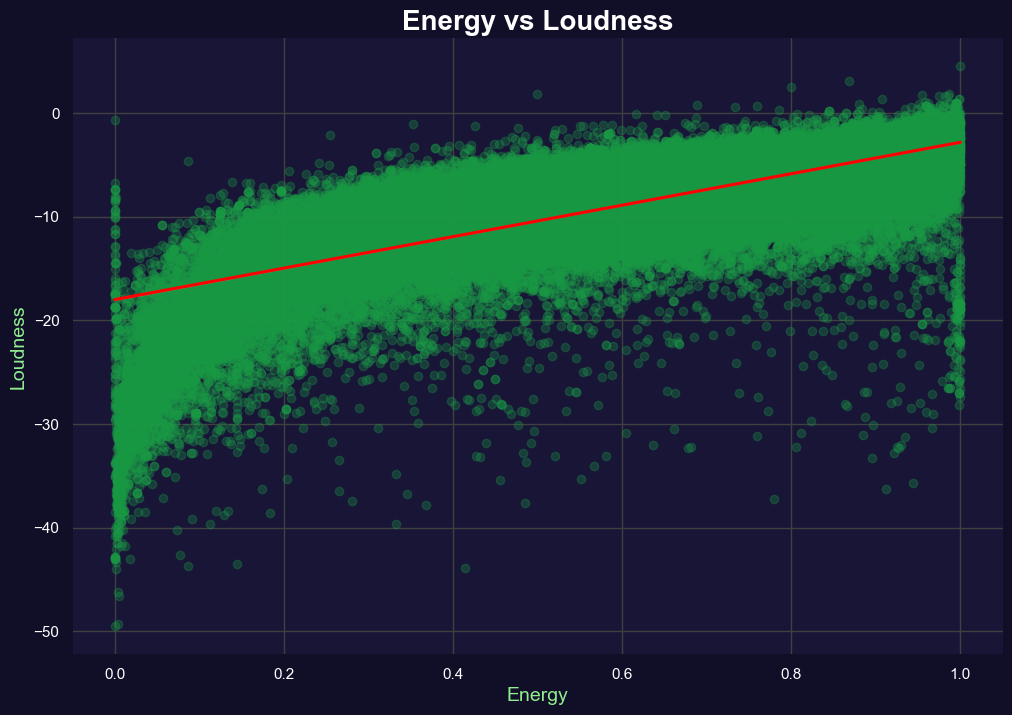

In [8]:
# 5. Energy vs Loudness (Scatter Plot with Regression Line)
# Question: How does the energy of a track relate to its loudness?

sns.regplot(
    data=df,
    x="energy",
    y="loudness",
    scatter_kws={"alpha": 0.3, "color": "#199A46"},
    line_kws={
        "color": "red"
    },  # line_kws={"color":"white"} sets the color of the regression line to white.
)
sns.despine(left=True, bottom=True)
plt.title("Energy vs Loudness", fontsize=20, fontweight="bold")
plt.xlabel("Energy", fontsize=14, color="lightgreen")
plt.ylabel("Loudness", fontsize=14, color="lightgreen")
plt.savefig("../images/energy_vs_loudness.png", dpi=300, bbox_inches="tight")
plt.show()
# Insight: The scatter plot with regression line shows the relationship between the energy and loudness of Spotify tracks. We can see that there is a positive correlation between energy and loudness, meaning that as the energy of a track increases, its loudness also tends to increase. This information can be useful for understanding how different audio features relate to each other and can help in making decisions about music production and playlist curation.

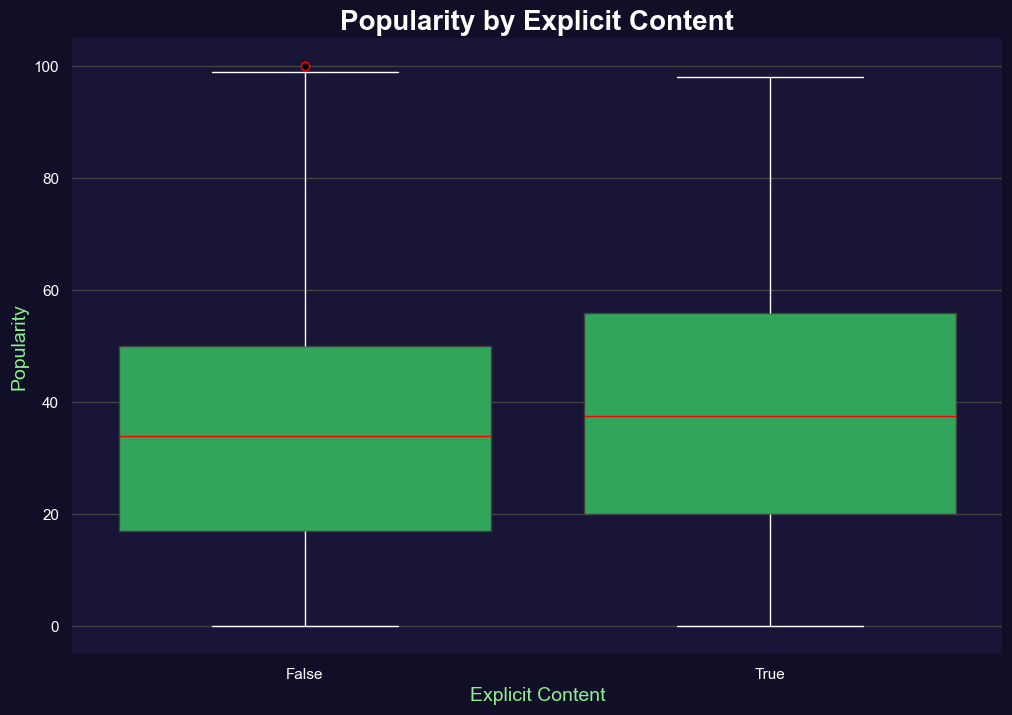

In [9]:
# 6. Popularity by Explicit Vs Non Explicit Content (Box Plot)
# Question: How does the popularity of explicit tracks compare to non-explicit tracks?

sns.boxplot(
    data=df,
    x="explicit",
    y="popularity",
    medianprops=dict(color="red"),
    whiskerprops=dict(color="white"),
    capprops=dict(color="white"),
    flierprops=dict(markerfacecolor="black", markeredgecolor="red"),
)

plt.title("Popularity by Explicit Content", fontsize=20, fontweight="bold")
plt.xlabel("Explicit Content", fontsize=14, color="lightgreen")
plt.ylabel("Popularity", fontsize=14, color="lightgreen")
sns.despine(left=True, bottom=True)
plt.savefig(
    "../images/popularity_by_explicit_content.png", dpi=300, bbox_inches="tight"
)
plt.show()

# Insight: The box plot shows the distribution of popularity scores for explicit and non-explicit tracks. We can see that explicit tracks tend to have a slightly higher median popularity score compared to non-explicit tracks. However, there is also more variability in the popularity scores of explicit tracks, as indicated by the wider interquartile range and the presence of outliers. This information can be useful for understanding how explicit content may impact the popularity of songs on Spotify and can help in making decisions about music production and marketing strategies.

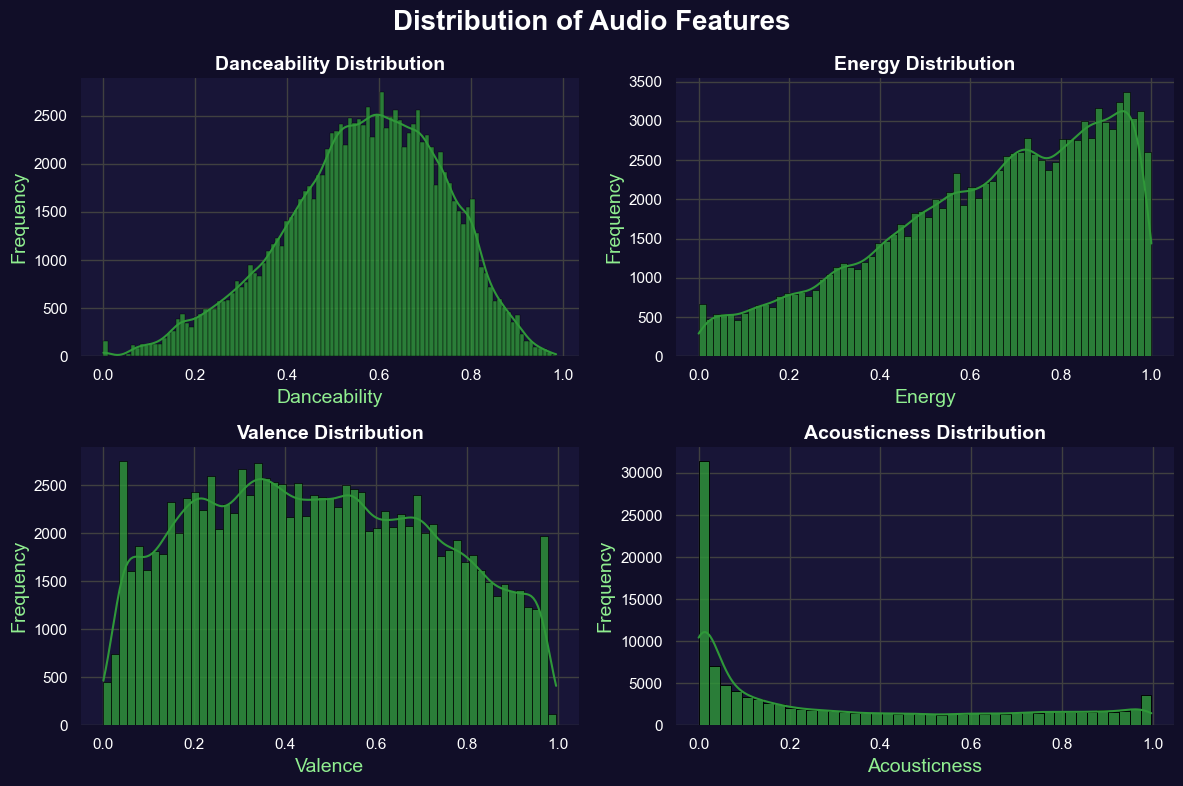

In [10]:
# 7. Distribution of Audio Features (Histograms)
# Question: What is the distribution of various audio features of Spotify tracks?
features = ["danceability", "energy", "valence", "acousticness"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(features, axes.flatten()):
    sns.histplot(
        df[feature], kde=True, edgecolor="black", ax=ax, color="#2F9839", alpha=0.8
    )
    sns.despine(left=True, bottom=True, ax=ax)
    ax.set_title(feature.capitalize() + " Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel(feature.capitalize(), fontsize=14, color="lightgreen")
    ax.set_ylabel("Frequency", fontsize=14, color="lightgreen")

plt.suptitle("Distribution of Audio Features", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "../images/distribution_of_audio_features.png", dpi=300, bbox_inches="tight"
)
plt.show()

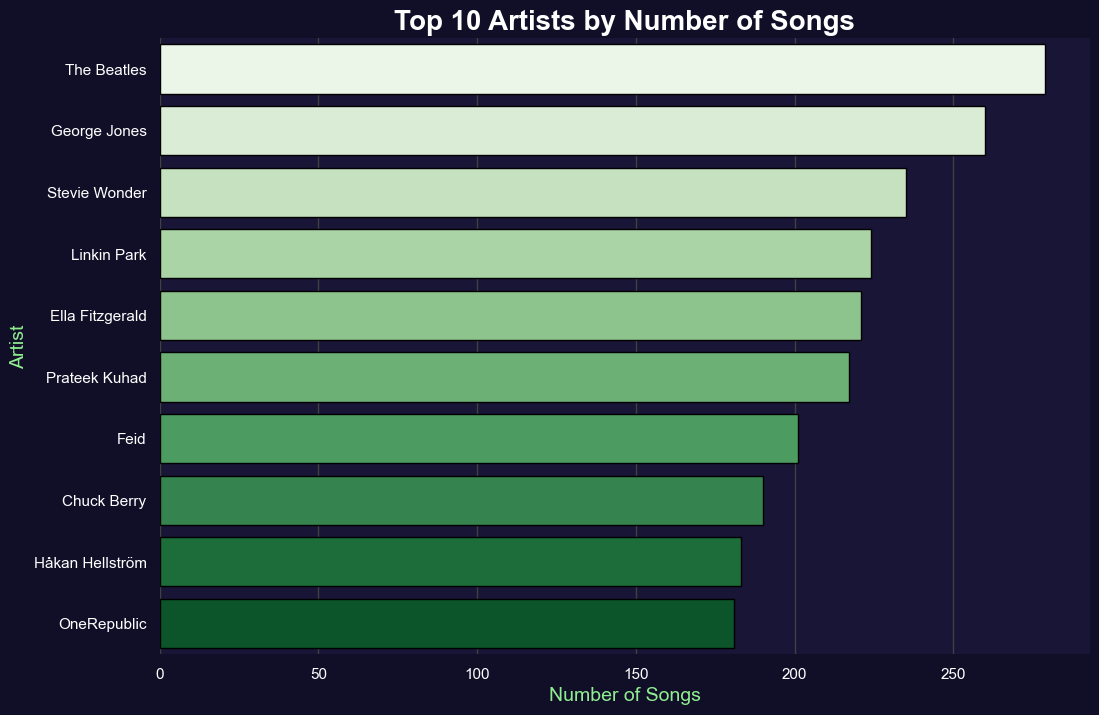

In [11]:
# 8. Top 10 Artists by Number of Songs (Bar Plot)
# Question: Who are the top 10 artists with the most songs in the dataset?
top_artists = df["artists"].value_counts().head(10)

sns.barplot(
    x=top_artists.values,
    y=top_artists.index,
    edgecolor="black",
    hue=top_artists.index,
    palette="Greens",
)
plt.title("Top 10 Artists by Number of Songs", fontsize=20, fontweight="bold")
plt.xlabel("Number of Songs", fontsize=14, color="lightgreen")
plt.ylabel("Artist", fontsize=14, color="lightgreen")
sns.despine(left=True, bottom=True)
plt.savefig("../images/top_10_artists.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight: The bar plot shows the top 10 artists with the most songs in the dataset. We can see that some artists have a significantly higher number of songs compared to others. This information can be useful for understanding which artists are more prolific in terms of song production and can help in making decisions about music promotion and marketing strategies.

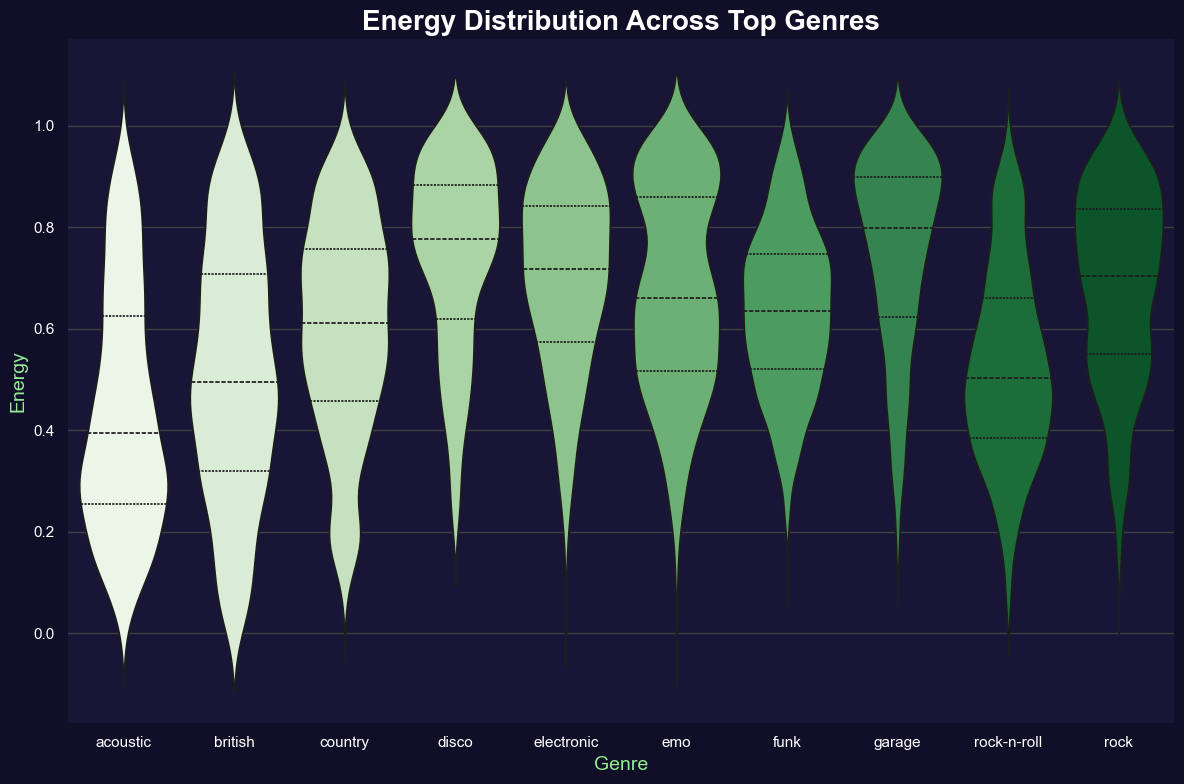

In [12]:
# 9. Energy Distribution Across Top Genres (Violin Plot)
# Question: How does the energy of tracks vary across different genres?
top10 = df["track_genre"].value_counts().head(10).index

sns.violinplot(
    data=df[df["track_genre"].isin(top10)],
    x="track_genre",
    y="energy",
    hue="track_genre",
    palette="Greens",
    inner="quartile",
)

# plt.xticks(rotation=45)
plt.title("Energy Distribution Across Top Genres", fontsize=20, fontweight="bold")
sns.despine(left=True, bottom=True)
plt.xlabel("Genre", fontsize=14, color="lightgreen")
plt.ylabel("Energy", fontsize=14, color="lightgreen")
plt.tight_layout()
plt.savefig(
    "../images/energy_distribution_across_top_genres.png", dpi=300, bbox_inches="tight"
)
plt.show()

# Insight: The violin plot shows the distribution of energy levels across the top 10 genres in the dataset. We can see that some genres have a wider range of energy levels, while others have a more concentrated distribution. This information can be useful for understanding how the energy of tracks varies across different genres and can help in making decisions about music production and playlist curation.

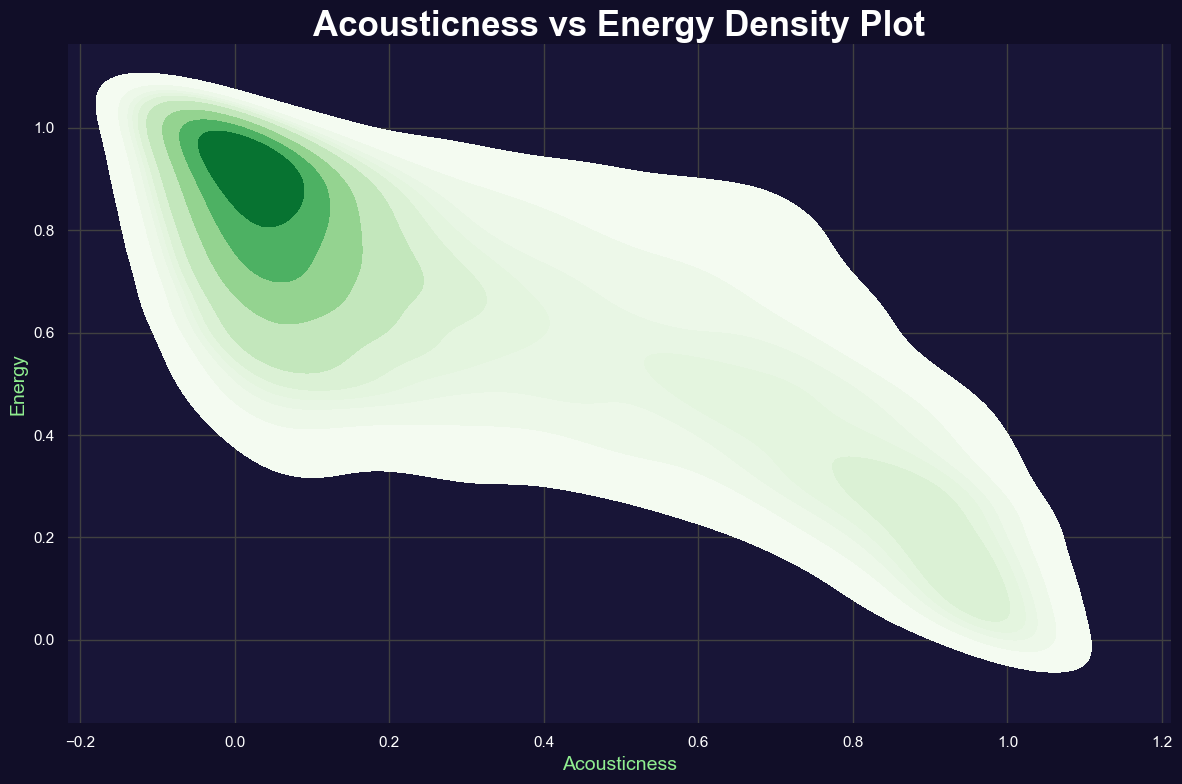

In [13]:
# 10. Acousticness vs Energy Density Plot (KDE Plot)
# Question: How do the acousticness and energy of tracks relate to each other?
sample_df = df.sample(10000, random_state=42)

sns.kdeplot(data=sample_df, x="acousticness", y="energy", fill=True, cmap="Greens")
plt.title("Acousticness vs Energy Density Plot", fontsize=25, fontweight="bold")
plt.xlabel("Acousticness", fontsize=14, color="lightgreen")
plt.ylabel("Energy", fontsize=14, color="lightgreen")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(
    "../images/acousticness_vs_energy_density_plot.png", dpi=300, bbox_inches="tight"
)
plt.show()
#

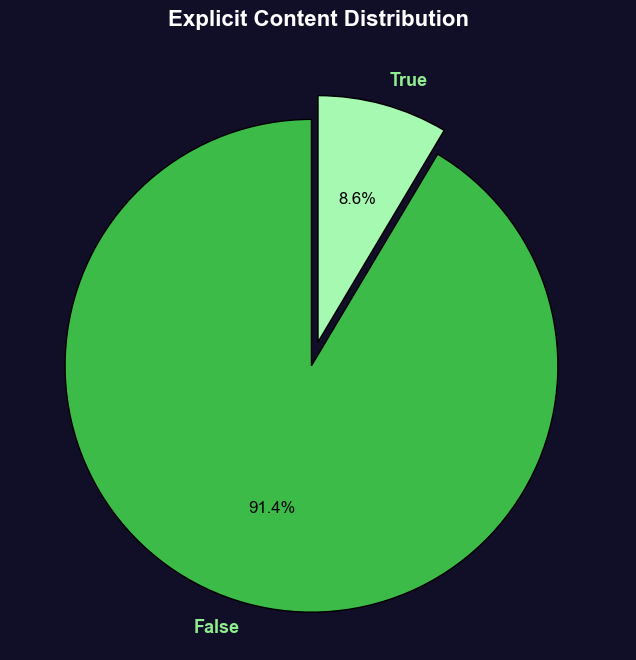

In [14]:
# 4. Pie Chart: explicit vs non-explicit content
# Question: What is the distribution of explicit vs non-explicit content in Spotify tracks?
# Note: seaborn has no pie-chart function, so this one stays on matplotlib's ax.pie (same formatting as before).

explicity = df["explicit"].value_counts()
colors = ["#3CBB49", "#A6F9B1"]


wedges, texts, autotexts = plt.pie(
    explicity,
    labels=explicity.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=(0.1, 0),
    wedgeprops={"edgecolor": "black"},
)
# make legend white
for text in texts:
    text.set_color("lightgreen")
    text.set_fontsize(13)
    text.set_fontweight("bold")

# Make percentages black
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(12)

plt.title(
    "Explicit Content Distribution", color="white", fontsize=16, fontweight="bold"
)

plt.savefig("../images/Explicit_Content.png", dpi=300, bbox_inches="tight")
plt.show()

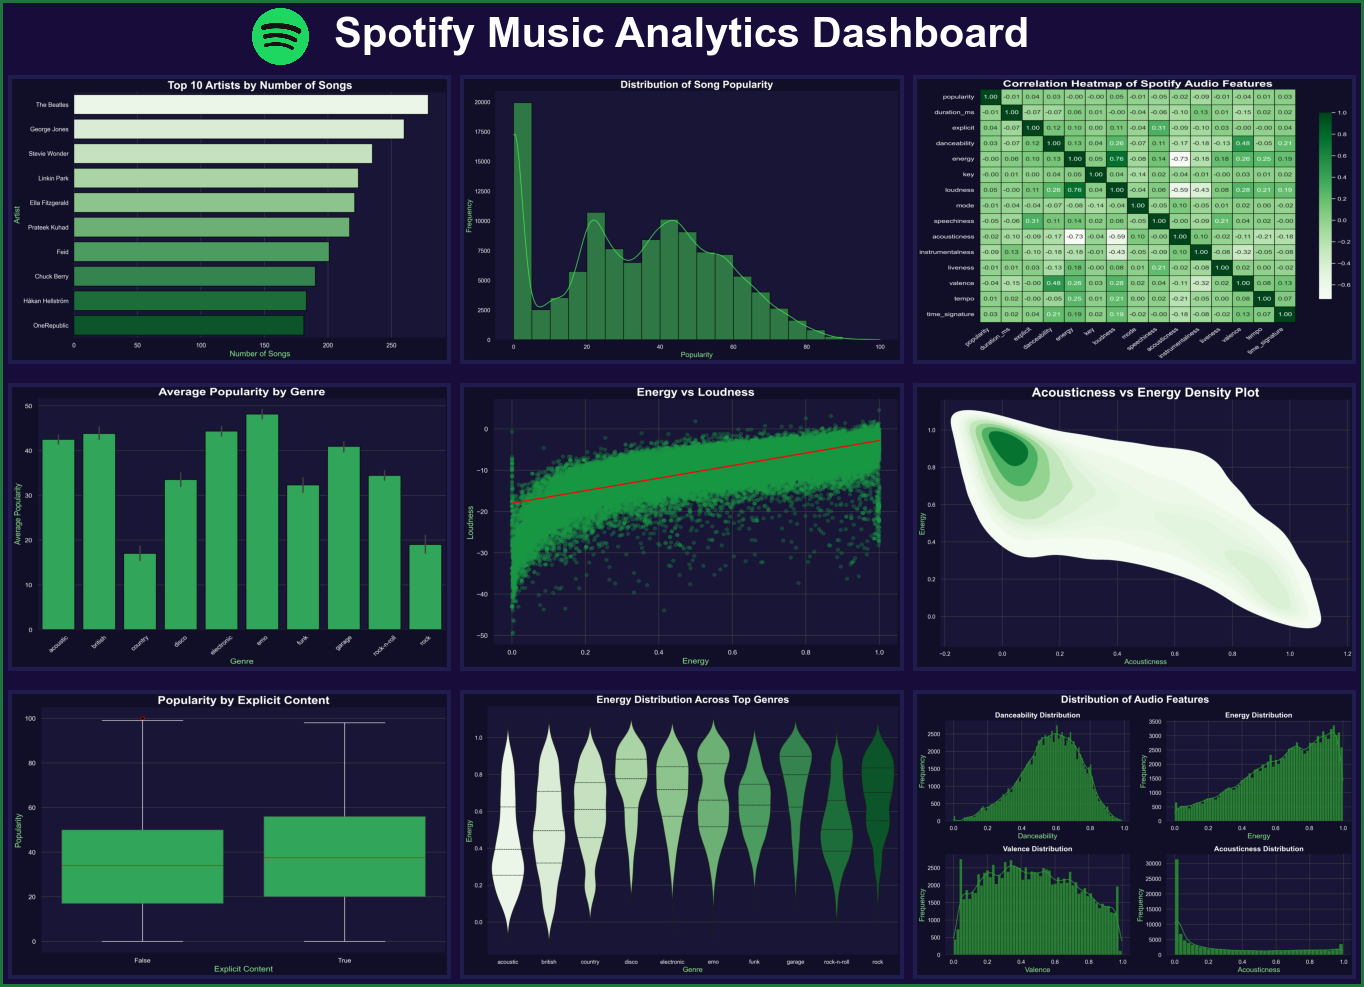

In [15]:
import matplotlib.pyplot as plt

images = [
    "../images/top_10_artists.png",
    "../images/popularity_distribution.png",
    "../images/correlation_heatmap.png",
    "../images/average_popularity_by_genre.png",
    "../images/energy_vs_loudness.png",
    "../images/acousticness_vs_energy_density_plot.png",
    "../images/popularity_by_explicit_content.png",
    "../images/energy_distribution_across_top_genres.png",
    "../images/distribution_of_audio_features.png",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

fig.patch.set_facecolor("#170C3A")
plt.subplots_adjust(
    wspace=0.03, hspace=0.08, left=0.02, right=0.98, top=0.92, bottom=0.02
)

for ax, img in zip(axes.ravel(), images):
    image = plt.imread(img)
    ax.imshow(image, aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#211C4E")
        spine.set_linewidth(3)

fig.patch.set_edgecolor("#1D773C")
fig.patch.set_linewidth(4)

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
logo = plt.imread("../data/spotify-logo.png")
imagebox = OffsetImage(logo, zoom=0.15)
ab = AnnotationBbox(
    imagebox,
    (0.20, 0.95),  # Adjust position
    xycoords="figure fraction",
    frameon=False,
)
fig.add_artist(ab)

fig.suptitle(
    "Spotify Music Analytics Dashboard",
    fontsize=30,
    color="white",
    fontweight="bold",
    y=0.98,
)
plt.savefig("../dashboard/Spotify_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()